# Stellar Coordinate Explorer - Hypothesis Testing: Are brigher stars closer?

## Objective
Test the hypothesis that stars with brighter apparent magnitude (lower G) tend to have larger parallax (i.e., be closer). Compute correlation coefficiennts and interpret the results.

## Dataset
- Random sample: `sources_with_galactic_coord_random.fits`

## Hypothesis
- **$H_{0}$** (null): No correlation between G magnitude and parallax.
- **$H_{1}$** (alternative): Significant negative correlation (brighter &rarr; larger parallax)

## Steps
1. Scatter plot: parallax vs G magnitude.
2. Computed Pearson and Spearman correlation coeffecients.
3. Colour points by colour index (`bp_rp`) to see if relation depends on stellar type.
4. Write observations.


## Code
### 1. Setup and Loading

In [1]:
# Imports
from astropy.table import Table
from scipy.stats import pearsonr, spearmanr
import matplotlib.pyplot as plt
import numpy as np
import textwrap


# Load the data in Table
table = Table.read("../../data/sources_with_galactic_coord_random.fits")

We can have a look at the sample size:

In [2]:
print(f"Sample size: {len(table)}")

Sample size: 10000


### 2. Scatter plot - magnitude vs parallax

Now we can add a plot to see if the apparent G-band magnitude shows variation with distance (`parallax`):

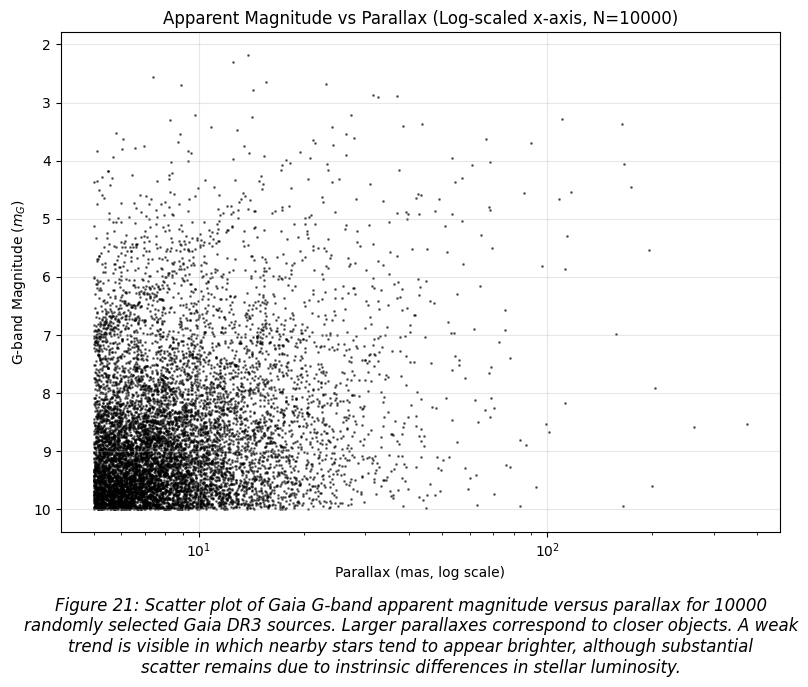

In [ ]:
# Apparent Magnitude (phot_g_mean_mag) vs Pallax (parallax) Scatter plot 

plt.figure(figsize=(8, 6))
plt.scatter(table['parallax'], table['phot_g_mean_mag'], s=1, alpha=0.5, c='black')
plt.xscale('log')
plt.xlabel('Parallax (mas, log scale)')
plt.ylabel(r'G-band Magnitude ($m_{G}$)')
plt.gca().invert_yaxis()     # brighter stars (low mag) at top
plt.title(f'Apparent Magnitude vs Parallax (Log-scaled x-axis, N={len(table)})')
plt.grid(True, alpha=0.3)

# Caption
fig_caption = r"""Figure 21: Scatter plot of Gaia G-band apparent magnitude versus parallax for 10000 randomly selected Gaia DR3 sources. Larger parallaxes correspond to closer objects.
A weak trend is visible in which nearby stars tend to appear brighter, although substantial scatter remains due to intrinsic differences in stellar luminosity.
"""
wrapper = textwrap.TextWrapper(width=90)
lines = wrapper.wrap(text=fig_caption)
fig_caption_wrapped = '\n'.join(lines)
plt.figtext(0.52, -0.13, fig_caption_wrapped, ha='center', fontsize=12, style='italic')

plt.tight_layout()
plt.show()

We can also add colour-index variation to the parallax vs apparent magnitude scatter plot:

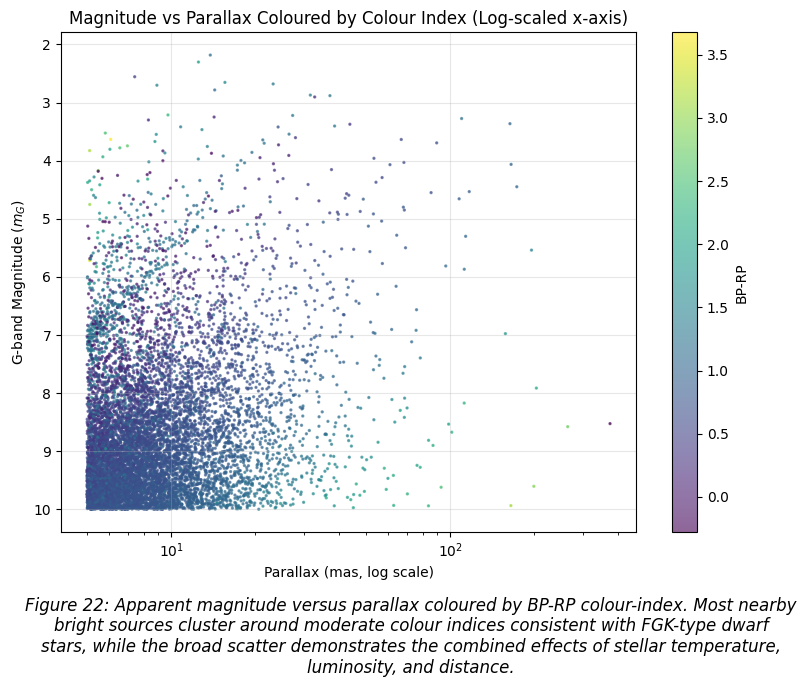

In [6]:
# Remove masked values for colour
mask = ~table['bp_rp'].mask

# Apparent Magnitude (phot_g_mean_mag) vs Pallax (parallax) Scatter Plot  with Colour-Index colourbar

plt.figure(figsize=(8, 6))
sc = plt.scatter(table['parallax'][mask], table['phot_g_mean_mag'][mask], c=table['bp_rp'][mask], cmap='viridis', s=2, alpha=0.6)
plt.xscale('log')
plt.colorbar(sc, label='BP-RP')
plt.xlabel('Parallax (mas, log scale)')
plt.ylabel(r'G-band Magnitude ($m_{G}$)')
plt.title(f"Magnitude vs Parallax Coloured by Colour Index (Log-scaled x-axis)")
plt.gca().invert_yaxis()
plt.grid(True, alpha=0.3)

# Caption
fig_caption = r"""Figure 22: Apparent magnitude versus parallax coloured by BP-RP colour-index. Most nearby bright sources cluster around moderate colour indices consistent with FGK-type
dwarf stars, while the broad scatter demonstrates the combined effects of stellar temperature, luminosity, and distance.
"""
wrapper = textwrap.TextWrapper(width=90)
lines = wrapper.wrap(text=fig_caption)
fig_caption_wrapped = '\n'.join(lines)
plt.figtext(0.52, -0.13, fig_caption_wrapped, ha='center', fontsize=12, style='italic')

plt.tight_layout()
plt.show()

### 2. Correlation Coefficients
Now we calculate both the Pearson and Spearman correlation coefficients and their corresponding p-values to determine if a statistical relationship exists between parallax and apparent magnitude of the sources. 

In [7]:
# Obtain the parallax and apparent magnitude values
parallax = table['parallax']
apparent_g_mag = table['phot_g_mean_mag']


# Obtain the correlation coefficients
pearson_r, pearson_p = pearsonr(parallax, apparent_g_mag)
spearman_r, spearman_p = spearmanr(parallax, apparent_g_mag)


print(f"Pearson r = {pearson_r:.3f}, p = {pearson_p:.2e}")
print(f"Spearman r = {spearman_r:.3f}, p = {spearman_p:.2e}")

Pearson r = -0.198, p = 4.81e-89
Spearman r = -0.190, p = 7.86e-82


We can also attempt to describe the parallax-magnitude relationship using a linear fit:

In [27]:
from scipy.stats import linregress
#  Fit line mag = a * parallax + b
slope, intercept, r_value, p_value, std_err = linregress(parallax, apparent_g_mag)

print(f"Linear fit: mag = {slope:.3f} * parallax + {intercept:.3f}")
print(f"r squared = {r_value ** 2:.3f}")

Linear fit: mag = -0.024 * parallax + 8.888
r squared = 0.039


## Observations
- A weak negative correlation was observed between apparent magnitude and parallax. This indicates that nearby stars tend to appear brighter on average.
- Both Pearson ($r = -0.198$) and Spearman ($r_{s} = -0.190$) correlation coefficients produced extremely small p-values, suggesting that the relationship is statistically significant despite its weakness. Therefore the null hypithesis is rejected.
- The low coefficient of determination ($R^{2}$ = 0.039) shows that distance alone explains only a small fraction of the variation in observed brightness. This reflects the intrinsic difference in stellar luminosities within the Gaia sample.
- The logarithmic parallax scale in Figure 21 and 22 reveal a weak trend in which nearby stars (larger parallaxes) tend to have lower apparent magnitudes and therefore appear brighter. However, substantial vertical scatter remains at similar parallaxes, reflecting the role of intrinsic luminosity in determining stellar brightness.
- The colour distribution in Figure 22 is dominated by moderate BP-RP values consistent with FGK-type stars in the randomly selected Gaia sources sample.